# CSI Machine Learning Project
Load dataset and display some samples

In [ ]:
import pandas as pd
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
import tensorflow as ts

# The grid is 5x7 coordinates. 
# Label 107 means x = 7, y = 1 somewhat confusing fixing "correct" tuple in the loop
# Define arrays for machine learing data and labels

X = []
y = []

for y_idx in range(1, 6):
    for x_idx in range(1, 8):
        label = int(f"{y_idx}0{x_idx}")
        path = f"CSI_dataset/miniLab/coordinate 1-35/{label}.mat"
        
        data = loadmat(path)
        arr = data["myData"]
        
        X.append(arr)
        y.append((x_idx, y_idx))

X = np.array(X)
y = np.array(y)

print("Data set size:")
print(X.shape)
print("Labels size:")
print(y.shape)

Data set size:
(35, 3, 30, 50)
Labels size:
(35, 2)


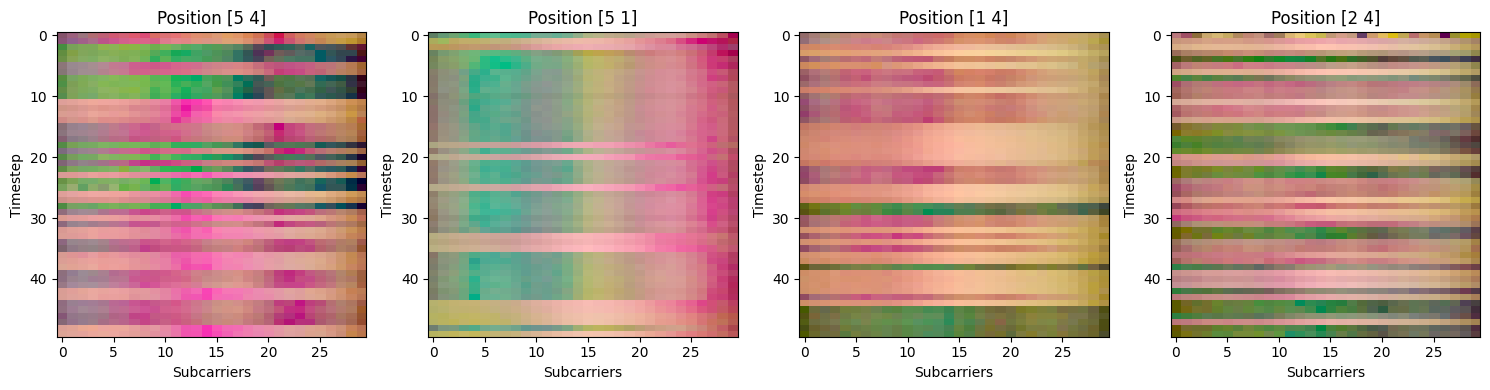

In [ ]:
import random

# List of positions to show
positions = np.random.randint(0, 35, 4)
fig, axes = plt.subplots(1, len(positions), figsize=(15,4))

for i, pos in enumerate(positions):

    # Get data
    sample = X[pos]
    img = np.transpose(sample, (2,1,0))
    
    # Normalize rgb 0-1
    img = (img - img.min()) / (img.max() - img.min())
    
    # Display images
    axes[i].imshow(img, aspect='auto')
    axes[i].set_title(f"Position {y[pos]}")
    axes[i].set_xlabel("Subcarriers")
    axes[i].set_ylabel("Timestep")

plt.tight_layout()
plt.show()

# Baseline machine learning (SVM, KNN, RFC)

Number of classes: 35
Feature shape: (1750, 90)
Labels shape: (1750,)
Train size: (1400, 90)
Test size: (350, 90)

SVM Accuracy: 0.8857142857142857
KNN Accuracy: 0.8885714285714286
Random Forest Accuracy: 0.9342857142857143


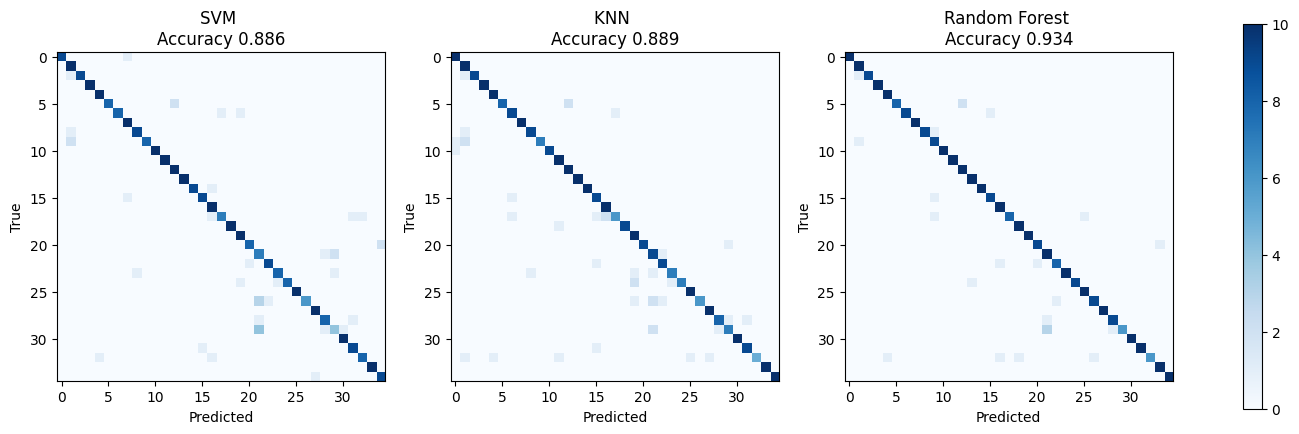

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier


# Convert labels to class index
classes = np.arange(len(y))  # 0..34
print("Number of classes:", len(classes))

# Reshape dataset for ML
locations, channels, subcarriers, timesteps = X.shape

# Move timestep dimension
X_temp = np.transpose(X, (0, 3, 1, 2))   # [35,50,3,30]

# Flatten features
X_ml = X_temp.reshape(locations * timesteps, channels * subcarriers)
print("Feature shape:", X_ml.shape)

# Create labels for samples
y_ml = np.repeat(classes, timesteps)
print("Labels shape:", y_ml.shape)

# Train test split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_ml,
    y_ml,
    test_size=0.2,
    random_state=42,
    stratify=y_ml
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train SVM
svm_model = SVC(kernel="rbf")
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)
print("\nSVM Accuracy:", svm_acc)

# Train KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)
print("KNN Accuracy:", knn_acc)

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_acc)

# Confusion Matrices
ccm_svm = confusion_matrix(y_test, svm_pred)
cm_knn = confusion_matrix(y_test, knn_pred)
cm_rf = confusion_matrix(y_test, rf_pred)

fig, axes = plt.subplots(1, 3, figsize=(18,5))

models = [
    ("SVM", cm_svm, svm_pred),
    ("KNN", cm_knn, knn_pred),
    ("Random Forest", cm_rf, rf_pred)
]

for ax, (name, cm, pred) in zip(axes, models):
    acc = accuracy_score(y_test, pred)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{name} \nAccuracy {acc:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

fig.colorbar(im, ax=axes.ravel().tolist())
plt.show()

# CNN (Convolutional Neural Network)

CNN input shape: (1750, 3, 30)
Labels shape: (1750,)
Train shape: (1400, 3, 30, 1)
Epoch 1/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0411 - loss: 3.5432 - val_accuracy: 0.1000 - val_loss: 3.5182
Epoch 2/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1312 - loss: 3.3706 - val_accuracy: 0.1143 - val_loss: 3.2152
Epoch 3/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2402 - loss: 2.8096 - val_accuracy: 0.2714 - val_loss: 2.6556
Epoch 4/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4214 - loss: 2.2933 - val_accuracy: 0.4393 - val_loss: 2.1350
Epoch 5/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5045 - loss: 1.9165 - val_accuracy: 0.5179 - val_loss: 1.7811
Epoch 6/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5714 - loss: 1.6302 - val_accuracy: 0.5857 - val_loss: 1.6190
Epoch 7/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6295 - loss: 1.4240 - val_accuracy: 0.5857 - val_loss: 1.3896
Epoch 8/20
35/35 ━━━━━━━━━━━━━━━━━

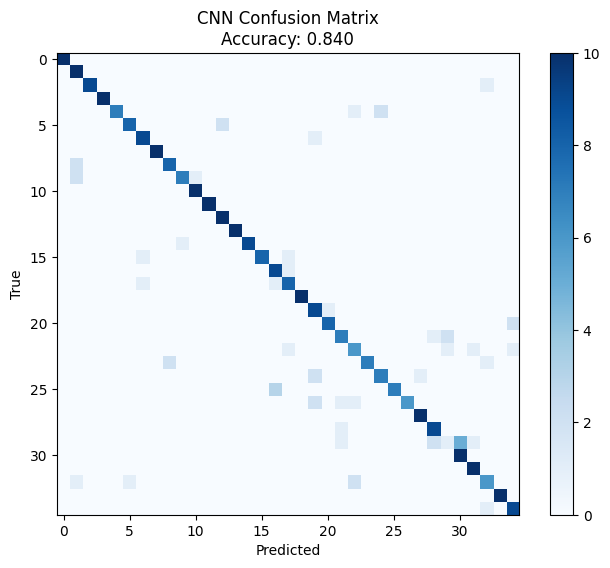

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models


# Create data
classes = np.arange(len(y))
locations, channels, subcarriers, timesteps = X.shape

X_temp = np.transpose(X, (0,3,1,2))   # [35,50,3,30]
X_cnn = X_temp.reshape(locations * timesteps, channels, subcarriers)
print("CNN input shape:", X_cnn.shape)

# Create labels
y_cnn = np.repeat(classes, timesteps)
print("Labels shape:", y_cnn.shape)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_cnn,
    y_cnn,
    test_size=0.2,
    random_state=42,
    stratify=y_cnn
)


# Add channel dimension
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]
print("Train shape:", X_train.shape)

# Normalize data
X_train = X_train / np.max(np.abs(X_train))
X_test = X_test / np.max(np.abs(X_test))

# CNN Model
model = models.Sequential([
    layers.Input(shape=(3,30,1)),        # <--- lägg till Input här
    layers.Conv2D(32, (2,3), activation='relu'),
    layers.MaxPooling2D((1,2)),
    layers.Conv2D(64, (2,3), activation='relu'),
    layers.MaxPooling2D((1,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(35, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

# Evaluate model
test_loss, test_acc = model.evaluate(X_test, y_test)
print("\nCNN Test Accuracy:", test_acc)

# Predictions
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()

plt.title(f"CNN Confusion Matrix\nAccuracy: {acc:.3f}")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

# Long Short-Term Memory (LTSM)

Sliding window input shape: (1435, 10, 90)
Labels shape: (1435,)
Train shape: (1148, 10, 90)
Test shape: (287, 10, 90)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 128)            │       112,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 35)             │         2,275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,659 (479.14 KB)

 Trainable params: 122,659 (479.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.0610 - loss: 3.4703 - val_accuracy: 0.0957 - val_loss: 3.3353
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1961 - loss: 2.9035 - val_accuracy: 0.2174 - val_loss: 2.5854
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4172 - loss: 2.0727 - val_accuracy: 0.5304 - val_loss: 1.7245
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6253 - loss: 1.4085 - val_accuracy: 0.6696 - val_loss: 1.2881
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7004 - loss: 1.0922 - val_accuracy: 0.7174 - val_loss: 0.9573
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7789 - loss: 0.7860 - val_accuracy: 0.6739 - val_loss: 1.0909
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8224 - loss: 0.6394 - val_accuracy: 0.7826 - val_loss: 0.6893
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8627 - loss: 0.5119 - val_accuracy: 0.7826 - v

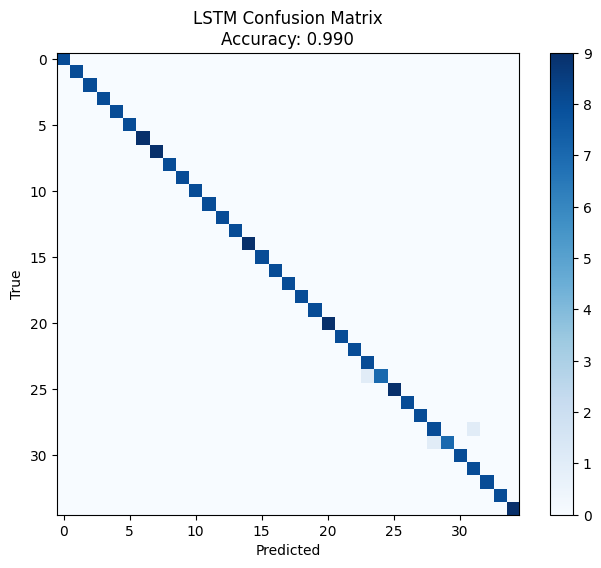

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Reshape for sliding window
locations, channels, subcarriers, timesteps = X.shape
X_temp = np.transpose(X, (0,3,1,2)) 

window_size = 10
X_lstm = []
y_lstm = []

for loc in range(locations):
    for start in range(timesteps - window_size + 1):
        window = X_temp[loc, start:start+window_size, :, :]
        X_lstm.append(window.reshape(window_size, channels*subcarriers))
        y_lstm.append(loc)

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

print("Sliding window input shape:", X_lstm.shape)
print("Labels shape:", y_lstm.shape)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_lstm, y_lstm, test_size=0.2, random_state=42, stratify=y_lstm
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Normalize features
X_train = X_train / np.max(np.abs(X_train))
X_test = X_test / np.max(np.abs(X_test))

# LSTM model
model = models.Sequential([
    layers.Input(shape=(window_size, channels*subcarriers)),
    layers.LSTM(128),
    layers.Dense(64, activation='relu'),
    layers.Dense(locations, activation='softmax')
])
model.summary()
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)
print("\nLSTM Test Accuracy:", test_acc)

# Predictions + Confusion Matrix
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.title(f"LSTM Confusion Matrix\nAccuracy: {acc:.3f}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# CNN + LSTM

Window input shape: (1435, 10, 3, 30)
Train shape: (1148, 10, 3, 30)
Test shape: (287, 10, 3, 30)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_15             │ (None, 10, 2, 28, 32)  │           224 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_16             │ (None, 10, 2, 14, 32)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_17             │ (None, 10, 896)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ (None, 10, 128)        │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 35)             │         2,275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 667,139 (2.54 MB)

 Trainable params: 667,139 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.0752 - loss: 3.4708 - val_accuracy: 0.1043 - val_loss: 3.2136
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.2800 - loss: 2.6492 - val_accuracy: 0.3348 - val_loss: 2.0597
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.5109 - loss: 1.7044 - val_accuracy: 0.6087 - val_loss: 1.3424
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.6699 - loss: 1.1102 - val_accuracy: 0.7957 - val_loss: 0.8350
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.7832 - loss: 0.7534 - val_accuracy: 0.8043 - val_loss: 0.7133
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.8159 - loss: 0.5994 - val_accuracy: 0.8957 - val_loss: 0.5044
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.8987 - loss: 0.3948 - val_accuracy: 0.9043 - val_loss: 0.3881
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.9336 - loss: 0.2980 - val_accuracy: 0.9348 - v

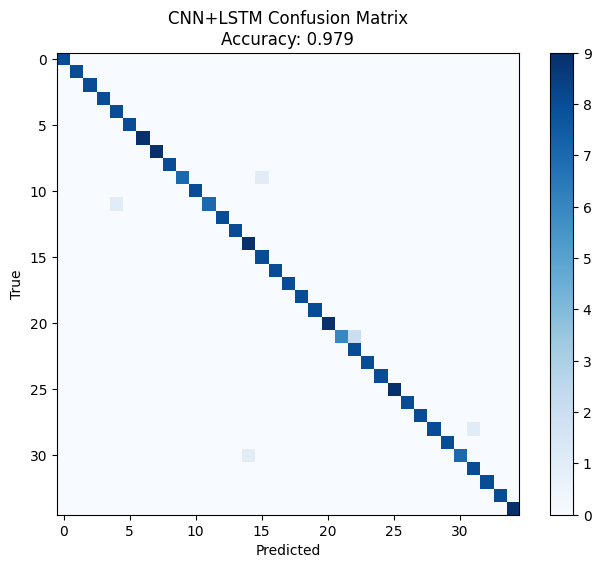

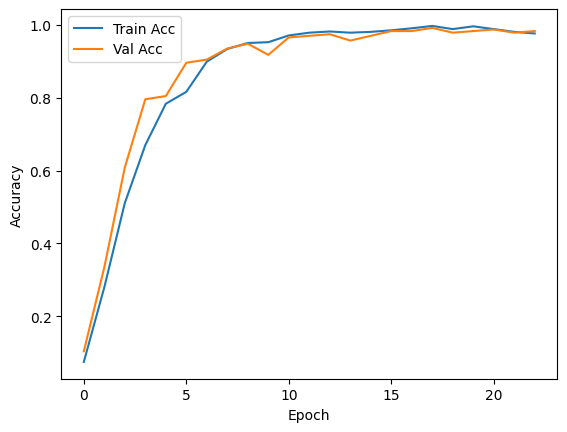

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Sliding windows
window_size = 10
X_window = []
y_window = []

for loc in range(locations):
    for start in range(timesteps - window_size + 1):
        window = X_temp[loc, start:start+window_size, :, :]
        X_window.append(window)
        y_window.append(loc)

X_window = np.array(X_window)  # [samples, window_size, channels, subcarriers]
y_window = np.array(y_window)
print("Window input shape:", X_window.shape)

# Normalize
X_window = X_window / np.max(np.abs(X_window))


# Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X_window, y_window, test_size=0.2, random_state=42, stratify=y_window
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


# CNN + LSTM model

model = models.Sequential([
    layers.Input(shape=(window_size, channels, subcarriers, 1)),  # [samples, 10, 3, 30, 1]
    layers.TimeDistributed(layers.Conv2D(32, (2,3), activation='relu')),
    layers.TimeDistributed(layers.MaxPooling2D((1,2))),
    layers.TimeDistributed(layers.Flatten()),
    layers.LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),  # <--- här
    layers.LSTM(128),  # sista LSTM kan vara return_sequences=False (default)
    layers.Dense(64, activation='relu'),
    layers.Dense(locations, activation='softmax')
])

model.summary()

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# Add channel dim for Conv2D

X_train_cnn = X_train[..., np.newaxis]  # [samples, window_size, channels, subcarriers, 1]
X_test_cnn = X_test[..., np.newaxis]


# Train

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,         # stoppa om val_loss inte förbättras 5 epochs
    restore_best_weights=True
)

history = model.fit(
    X_train_cnn, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)


# Evaluate

test_loss, test_acc = model.evaluate(X_test_cnn, y_test)
print("\nCNN+LSTM Test Accuracy:", test_acc)


# Predictions + Confusion Matrix

y_pred_prob = model.predict(X_test_cnn)
y_pred = np.argmax(y_pred_prob, axis=1)

cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.title(f"CNN+LSTM Confusion Matrix\nAccuracy: {acc:.3f}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# CNN + LSTM with LOLO (Leave One Location Out)

Total samples: 1435
Train samples: 1394, Test samples: 41


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_21             │ (None, 10, 2, 28, 32)  │           224 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_22             │ (None, 10, 2, 14, 32)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_23             │ (None, 10, 896)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 10, 128)        │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 35)             │         2,275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 667,139 (2.54 MB)

 Trainable params: 667,139 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.0744 - loss: 3.4180 - val_accuracy: 0.0000e+00 - val_loss: 4.7008
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.2762 - loss: 2.5168 - val_accuracy: 0.0000e+00 - val_loss: 6.5313
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.5713 - loss: 1.5319 - val_accuracy: 0.0000e+00 - val_loss: 8.7434
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.7677 - loss: 0.8363 - val_accuracy: 0.0000e+00 - val_loss: 9.5877
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.8897 - loss: 0.4460 - val_accuracy: 0.0000e+00 - val_loss: 10.8433
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.9103 - loss: 0.3340 - val_accuracy: 0.0000e+00 - val_loss: 11.0891
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.0000e+00 - loss: 4.9881

CNN+LSTM LOLO Test Accuracy (location 0): 0.000
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/stepWARNING:tensorflow:6 out of the last 13 calls to 

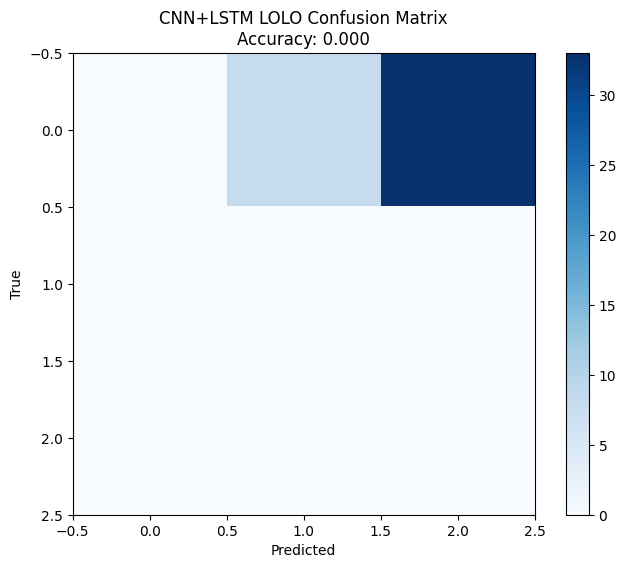

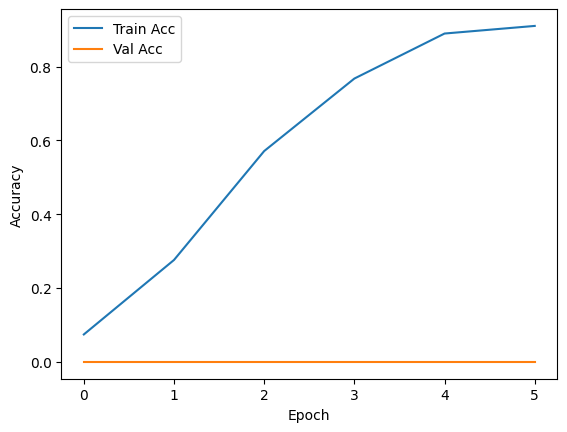

In [ ]:
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix, accuracy_score


# Load CSI dataset

X = []
y_coords = []

for y_idx in range(1, 6):
    for x_idx in range(1, 8):
        label = int(f"{y_idx}0{x_idx}")
        path = f"CSI_dataset/miniLab/coordinate 1-35/{label}.mat"
        data = loadmat(path)
        arr = data["myData"]
        X.append(arr)
        y_coords.append((x_idx, y_idx))

X = np.array(X)  # [35,3,30,50]
locations, channels, subcarriers, timesteps = X.shape
X_temp = np.transpose(X, (0,3,1,2))  # [35,50,3,30]

window_size = 10


# Sliding windows per location

X_window = []
y_window = []
location_ids = []

for loc in range(locations):
    for start in range(timesteps - window_size + 1):
        window = X_temp[loc, start:start+window_size, :, :]  # [10,3,30]
        X_window.append(window)
        y_window.append(loc)          # location label
        location_ids.append(loc)      # keep track of location for LOLO split

X_window = np.array(X_window)  # [samples, window_size, channels, subcarriers]
y_window = np.array(y_window)
location_ids = np.array(location_ids)

# Normalize
X_window = X_window / np.max(np.abs(X_window))

print("Total samples:", X_window.shape[0])


# Leave-One-Location-Out (LOLO) split

test_loc = 0  # testa på location 0 (första location)
train_idx = location_ids != test_loc
test_idx = location_ids == test_loc

X_train, X_test = X_window[train_idx], X_window[test_idx]
y_train, y_test = y_window[train_idx], y_window[test_idx]

print(f"Train samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

# Add channel dim for Conv2D
X_train = X_train[..., np.newaxis]  # [samples, window_size, channels, subcarriers, 1]
X_test = X_test[..., np.newaxis]


# CNN + LSTM model

model = models.Sequential([
    layers.Input(shape=(window_size, channels, subcarriers, 1)),
    layers.TimeDistributed(layers.Conv2D(32, (2,3), activation='relu')),
    layers.TimeDistributed(layers.MaxPooling2D((1,2))),
    layers.TimeDistributed(layers.Flatten()),
    layers.LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
    layers.LSTM(128),
    layers.Dense(64, activation='relu'),
    layers.Dense(locations, activation='softmax')
])

model.summary()

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


# Train

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)


# Evaluate

test_loss, test_acc = model.evaluate(X_test, y_test)
print("\nCNN+LSTM LOLO Test Accuracy (location {}): {:.3f}".format(test_loc, test_acc))


# Confusion Matrix

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.title(f"CNN+LSTM LOLO Confusion Matrix\nAccuracy: {acc:.3f}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


# Train/Val Accuracy Plot

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

The model is shit

Total samples: 1435

=== Testing location 0 ===
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 720ms/step
Accuracy for location 0: 0.000

=== Testing location 1 ===
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 710ms/step
Accuracy for location 1: 0.000

=== Testing location 2 ===
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 597ms/step
Accuracy for location 2: 0.000

=== Testing location 3 ===
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 669ms/step
Accuracy for location 3: 0.000

=== Testing location 4 ===
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 721ms/step
Accuracy for location 4: 0.000

=== Testing location 5 ===
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 671ms/step
Accuracy for location 5: 0.000

=== Testing location 6 ===
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 718ms/step
Accuracy for location 6: 0.000

=== Testing location 7 ===
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 607ms/step
Accuracy for location 7: 0.000

=== Testing location 8 ===
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 593ms/step
Accuracy for location 8: 0.000

=== Testing location 9 ===
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 649ms/step
Accuracy for location 9: 0.000


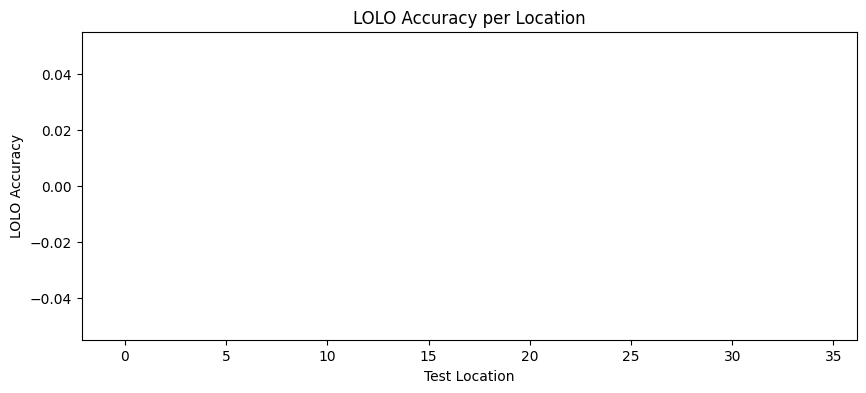

In [ ]:
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import accuracy_score


# Load CSI dataset

X = []
y_coords = []

for y_idx in range(1, 6):
    for x_idx in range(1, 8):
        label = int(f"{y_idx}0{x_idx}")
        path = f"CSI_dataset/miniLab/coordinate 1-35/{label}.mat"
        data = loadmat(path)
        arr = data["myData"]
        X.append(arr)
        y_coords.append((x_idx, y_idx))

X = np.array(X)  # [35,3,30,50]
locations, channels, subcarriers, timesteps = X.shape
X_temp = np.transpose(X, (0,3,1,2))  # [35,50,3,30]

window_size = 10


# Sliding windows per location

X_window = []
y_window = []
location_ids = []

for loc in range(locations):
    for start in range(timesteps - window_size + 1):
        window = X_temp[loc, start:start+window_size, :, :]
        X_window.append(window)
        y_window.append(loc)
        location_ids.append(loc)

X_window = np.array(X_window)  # [samples, window_size, channels, subcarriers]
y_window = np.array(y_window)
location_ids = np.array(location_ids)

# Normalize
X_window = X_window / np.max(np.abs(X_window))

print("Total samples:", X_window.shape[0])


# CNN+LSTM model builder

def build_model():
    model = models.Sequential([
        layers.Input(shape=(window_size, channels, subcarriers, 1)),
        layers.TimeDistributed(layers.Conv2D(16, (2,3), activation='relu')),  # mindre filter
        layers.TimeDistributed(layers.MaxPooling2D((1,2))),
        layers.TimeDistributed(layers.Flatten()),
        layers.LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
        layers.LSTM(64),
        layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        layers.Dense(locations, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# LOLO evaluation

accuracies = []

for test_loc in range(locations):
    print(f"\n=== Testing location {test_loc} ===")
    
    train_idx = location_ids != test_loc
    test_idx = location_ids == test_loc
    
    X_train, X_test = X_window[train_idx], X_window[test_idx]
    y_train, y_test = y_window[train_idx], y_window[test_idx]
    
    # Add channel dim
    X_train_cnn = X_train[..., np.newaxis]
    X_test_cnn = X_test[..., np.newaxis]
    
    model = build_model()
    
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
    
    history = model.fit(
        X_train_cnn, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0
    )
    
    y_pred_prob = model.predict(X_test_cnn)
    y_pred = np.argmax(y_pred_prob, axis=1)
    
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy for location {test_loc}: {acc:.3f}")
    accuracies.append(acc)


# Summary

accuracies = np.array(accuracies)
print("\nLOLO Mean Accuracy: {:.3f}, Std: {:.3f}".format(accuracies.mean(), accuracies.std()))

plt.figure(figsize=(10,4))
plt.bar(range(locations), accuracies)
plt.xlabel("Test Location")
plt.ylabel("LOLO Accuracy")
plt.title("LOLO Accuracy per Location")
plt.show()